In [1]:
import numpy as np
import pandas as pd

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import torch.utils.data as data_utils 


import warnings
with warnings.catch_warnings():
    warnings.filterwarnings("ignore",category=DeprecationWarning)
    import pytorch_lightning as pl
from pytorch_lightning.loggers import CSVLogger

import seaborn as sns


# local imports
import utils 
from train_vaes_phils_nb import get_aaindex_embedding

In [2]:
from tqdm.notebook import tqdm

In [3]:
from rosetta_db import get_sqlite_dbcon
db_con = get_sqlite_dbcon(parent="2D")
df = pd.read_sql("select r.*, d.* from relaxed_scores as r "
                 "inner join docked_scores as d on d.variant = r.variant;"
                 , db_con)

# We have duplicated column names because they have similar names in the two columns
# now relabel the columns so that the first columns are prepended with r_ for relaxation
# and the second set of columns are prepended with d_ for docking

# description should occur twice in the database columns. Find out where
desciption_idxs = np.where(df.columns == "description")[0]
assert(len(desciption_idxs) == 2)
table_split = desciption_idxs[0] + 1

df.columns = ["r_" + c for c in df.columns[:table_split]] \
           + ["d_" + c for c in df.columns[table_split:-1]] \
           + [df.columns[-1]] # this is "variant", the key for joining so it only appears once

# For relaxed_scores it is always the same structure e.g. SadA_NSLeu_2D_0001_0001 as we only do one structure
# For docked_scores it is the best structure out of nstructs=100. 
# We do not need this information for modeling

columns_to_drop = ["r_description","d_description", "d_variant" ] # which structure was selected. 
columns_to_drop.append("r_dslf_fa13") # from relaxed scores

# columns to delete from docked scores
# These are all constant (std = 0)
columns_to_drop += list(df.describe().loc[:, df.describe().loc['std'] == 0].columns)

print(f"Dropping {len(columns_to_drop)} columns: ", columns_to_drop)
df.drop(columns=columns_to_drop, inplace=True)

print()
print(f"Keeping  {len(columns_to_drop)} columns: ", list(df.columns))

df.head()

Dropping 30 columns:  ['r_description', 'd_description', 'd_variant', 'r_dslf_fa13', 'r_dslf_fa13', 'd_angle_constraint', 'd_atom_pair_constraint', 'd_chainbreak', 'd_dihedral_constraint', 'd_dslf_ca_dih', 'd_dslf_cs_ang', 'd_dslf_ss_dih', 'd_dslf_ss_dst', 'd_if_X_angle_constraint', 'd_if_X_atom_pair_constraint', 'd_if_X_chainbreak', 'd_if_X_coordinate_constraint', 'd_if_X_dihedral_constraint', 'd_if_X_dslf_ca_dih', 'd_if_X_dslf_cs_ang', 'd_if_X_dslf_ss_dih', 'd_if_X_dslf_ss_dst', 'd_if_X_fa_dun', 'd_if_X_hbond_lr_bb', 'd_if_X_hbond_sr_bb', 'd_if_X_omega', 'd_if_X_p_aa_pp', 'd_if_X_pro_close', 'd_if_X_ref', 'd_ligand_is_touching_X']

Keeping  30 columns:  ['r_total_score', 'r_fa_atr', 'r_fa_dun', 'r_fa_elec', 'r_fa_intra_rep', 'r_fa_intra_sol_xover4', 'r_fa_rep', 'r_fa_sol', 'r_hbond_bb_sc', 'r_hbond_lr_bb', 'r_hbond_sc', 'r_hbond_sr_bb', 'r_lk_ball_wtd', 'r_omega', 'r_p_aa_pp', 'r_pro_close', 'r_rama_prepro', 'r_ref', 'r_yhh_planarity', 'd_total_score', 'd_Grid_score', 'd_Transform_ac

,r_total_score,r_fa_atr,r_fa_dun,r_fa_elec,r_fa_intra_rep,r_fa_intra_sol_xover4,r_fa_rep,r_fa_sol,r_hbond_bb_sc,r_hbond_lr_bb,...,d_if_X_fa_sol,d_if_X_hbond_bb_sc,d_if_X_hbond_sc,d_interface_delta_X,d_omega,d_p_aa_pp,d_pro_close,d_ref,d_total_score_X,variant
0,-854.046,-1547.960,312.281,-531.071,2.815,54.993,179.953,923.799,-55.735,-83.625,...,7.740,-3.733,-2.840,-10.495,48.539,-42.449,1.057,-44.53,-29.0,F240S
1,-844.229,-1562.435,321.579,-535.211,2.884,56.004,184.718,941.687,-56.275,-82.617,...,8.260,-5.314,-0.423,-11.265,50.349,-41.727,1.029,-45.96,-29.0,A187R.V39N.F62K
2,-826.918,-1569.686,312.137,-516.471,3.134,56.338,185.486,918.217,-54.229,-83.145,...,6.567,-1.979,-3.298,-9.093,48.736,-41.179,1.080,-39.69,-29.0,D190I.Q236I.T254S.E134P.E208C.G180R.A69W
3,-848.450,-1563.670,324.802,-541.695,2.829,56.087,182.194,948.365,-58.665,-82.374,...,11.059,-0.351,-9.971,-12.745,48.305,-43.662,1.040,-40.86,-29.0,H3W.V142G.T254P.F150W.A18R.G79Q.A15C.A187T.I248R
4,-859.796,-1556.332,312.891,-534.450,2.852,55.373,180.526,928.443,-57.656,-83.463,...,6.634,-0.322,-3.433,-7.656,48.245,-42.532,1.132,-47.13,-30.0,F97L.H210R


In [4]:
# drop the first r_energy term (r_total_score) and sum up the other r_ energy terms
# we should get something very close to the r_total_score
print(f"Sum of r_ energy terms for first variant : {df.loc[0, df.columns.str.startswith('r_')][1:].sum():.4f}")
print(f"    Total energy terms for first variant : {df.loc[0, 'r_total_score']:.4f}")

Sum of r_ energy terms for first variant : -854.0440
    Total energy terms for first variant : -854.0460


In [5]:
# The same thing isn't true for the d_ scores
# drop the first d_energy term (d_total_score) and sum up the other d_ energy terms
# we do not get something very close to the d_total_score
print(f"Sum of d_ energy terms for first variant : {df.loc[0, df.columns.str.startswith('d_')][1:].sum():.4f}")
print(f"    Total energy terms for first variant : {df.loc[0, 'd_total_score']:.4f}")

Sum of d_ energy terms for first variant : -1003.2480
    Total energy terms for first variant : -894.0480


In [6]:
# setup torchtext vocab to map AAs to indices, usage is aa2ind(list(AAsequence))
AAs = 'ACDEFGHIKLMNPQRSTVWY'
aa2ind_dict = {a:i for i, a in enumerate(AAs)}

In [7]:
class RosettaSQLdf(torch.utils.data.Dataset):
   
    def __init__(self, df, parent_seq, dtype=torch.float32):
        self.df = df
        self.dtype = dtype
        self.parent_seq = parent_seq
        self.parent_enc = list(map(aa2ind_dict.get, self.parent_seq))
        
    def __getitem__(self, idx):
        energies = torch.tensor(self.df.iloc[idx][1:-1], dtype=self.dtype)
        seq_list = utils.expand_mut_str_list_to_list(
                df.iloc[idx, -1], self.parent_enc, encoder=aa2ind_dict.get,
                split_mut_char=".", offset=1)
        seq = torch.tensor(seq_list, dtype=torch.int)
        return seq, energies

    def __len__(self):
        return len(self.df)

In [8]:
class RosettaEnergiesDataModule(pl.LightningDataModule):
    
    def __init__(self, parent = "2D", batch_size=32, dtype=torch.float32):
        super().__init__()
        self.parent = parent
        self.batch_size = batch_size
        self.dtype = dtype
        
        # read sequence and encode
        self.parent_seq = utils.get_parent_seq(parent=self.parent)
        self.slen = len(self.parent_seq)
        #self.parent_enc = list(map(aa2ind_dict.get, self.parent))

        # read in data from database
        db_con = get_sqlite_dbcon(parent=self.parent)
        self.df = pd.read_sql("select * from relaxed_scores", db_con)
        
        del self.df["description"]
        del self.df["dslf_fa13"] # disulfide bond energy
        
        # number of parameters to predict
        self.nparam = len(self.df.columns) - 2 # dropping first (total energy) and last column (variant)

        
        N = len(self.df)
        train_val_test_split = [0.8, 0.1, 0.1]
        n_train_val_test = np.round(np.array(train_val_test_split)*N).astype(int)
        n_train_val_test[-1] = (N  - n_train_val_test[:-1].sum())
        self.train_idx, self.val_idx, self.test_idx = \
                data_utils.random_split(range(N),n_train_val_test)

    def prepare_data(self):
        # prepare_data is called from a single GPU. Do not use it to assign state (self.x = y)
        # use this method to do things that might write to disk or that need to be done only from a single process
        # in distributed settings.
        pass

    
    def setup(self, stage=None):
              
        # Assign train/val datasets for use in dataloaders
        if stage == 'fit' or stage is None:
            self.train_data = RosettaSQLdf(self.df.iloc[list(self.train_idx),], self.parent_seq)
            self.val_data = RosettaSQLdf(self.df.iloc[list(self.val_idx),], self.parent_seq)
            
        # Assign test dataset for use in dataloader(s)
        if stage == 'test' or stage is None:
            self.test_data = RosettaSQLdf(self.df.iloc[list(self.test_idx),], self.parent_seq)

    def train_dataloader(self):
        return data_utils.DataLoader(self.train_data, batch_size=self.batch_size, shuffle=True)

    def val_dataloader(self):
        return data_utils.DataLoader(self.val_data, batch_size=self.batch_size)

    def test_dataloader(self):
        return data_utils.DataLoader(self.test_data, batch_size=self.batch_size)

rd = RosettaEnergiesDataModule(parent="2D")

In [9]:
rd.setup()

In [10]:
for x in rd.test_dataloader():
    break
print(x[0].shape)
print(x[1].shape)

torch.Size([32, 273])
torch.Size([32, 18])


In [11]:
class RosettaEnergyPrediction(pl.LightningModule):
    
    def __init__(self, slen, nparam, embed_ncomp=0, embed_freeze=True, learning_rate=0.01, ):
        
        super().__init__()

        ## GENERAL INPUT PARAMETERS
        self.slen = slen # sequence length
        self.nparam = nparam # number of energy terms to predict
        self.q = 20 # amino acid alphabet_size (without gaps)
        
        self.learning_rate = learning_rate
        
        if embed_ncomp: # if non-zero get a pretrained PCA embedding of Amino acids based on physiochemical properties
            aaindex = get_aaindex_embedding(ncomp=embed_ncomp)
            aaindex = aaindex[:-1, :] # drop the gap character
            assert(aaindex.shape[0] == self.q)
        else: # if embed_ncomp is zero then do one-hot encoding
            aaindex = torch.eye(self.q)
        self.embed = nn.Embedding.from_pretrained(aaindex, freeze=embed_freeze)
        self.edim = self.embed.embedding_dim # dimensions of AA embedding
       
        self.flatten = nn.Flatten()
        self.linear = nn.Linear(self.edim*self.slen, self.nparam)
        
        
        # save hyperparameters for logging 
        self.save_hyperparameters()
        
    def forward(self, x):
        x = self.embed(x)
        x = self.flatten(x)
        x = self.linear(x)
        return x
    
    def shared_step(self, batch):
        x, y = batch
        # pass through network
        out = self(x)
        
        # calculate loss
        return nn.MSELoss()(out, y)
        
    def training_step(self, batch, batch_idx):
        loss = self.shared_step(batch)
        self.log("train_loss", loss, prog_bar=False, logger=True, on_step = False, on_epoch=True)
        #self.log("train_loss", loss, on_epoch=True)
        return loss
    
    def validation_step(self, batch, batch_idx):
        loss = self.shared_step(batch)
        #self.log("val_loss", loss, on_epoch=True)

        self.log("val_loss", loss, prog_bar=False, logger=True, on_step = False, on_epoch=True)
        return loss
    
    def test_step(self, batch, batch_idx):
        return self.shared_step(batch)
    
    def configure_optimizers(self):
        optimizer = torch.optim.Adam(self.parameters(), lr=self.learning_rate)
        return optimizer

In [12]:
dm = RosettaEnergiesDataModule(parent = "2D")

In [13]:
#model = RosettaEnergyPrediction(slen=dm.slen, nparam=dm.nparam, embed_freeze=True, embed_ncomp=8)
model = RosettaEnergyPrediction(slen=dm.slen, nparam=dm.nparam)

In [14]:
# train 
logger = CSVLogger('logs', name='Linear')
trainer = pl.Trainer(logger=logger,max_epochs=50,gpus=0)
trainer.fit(model,dm)

GPU available: False, used: False
TPU available: False, using: 0 TPU cores
IPU available: False, using: 0 IPUs

  | Name    | Type      | Params
--------------------------------------
0 | embed   | Embedding | 400   
1 | flatten | Flatten   | 0     
2 | linear  | Linear    | 98.3 K
--------------------------------------
98.3 K    Trainable params
400       Non-trainable params
98.7 K    Total params
0.395     Total estimated model params size (MB)


/home/romeroroot/miniconda3/lib/python3.9/site-packages/pytorch_lightning/trainer/data_loading.py:105: UserWarning: The dataloader, val dataloader 0, does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` (try 32 which is the number of cpus on this machine) in the `DataLoader` init to improve performance.
  rank_zero_warn(
/home/romeroroot/miniconda3/lib/python3.9/site-packages/pytorch_lightning/trainer/data_loading.py:105: UserWarning: The dataloader, train dataloader, does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` (try 32 which is the number of cpus on this machine) in the `DataLoader` init to improve performance.
  rank_zero_warn(
/home/romeroroot/miniconda3/lib/python3.9/site-packages/pytorch_lightning/trainer/data_loading.py:322: UserWarning: The number of training samples (29) is smaller than the logging interval Trainer(log_every_n_steps=50). Set a lowe

Epoch 0:  88% 29/33 [00:00<00:00, 70.08it/s, loss=1.87e+05, v_num=15]
Validating: 0it [00:00, ?it/s]
Epoch 0: 100% 33/33 [00:00<00:00, 71.72it/s, loss=1.87e+05, v_num=15]
Epoch 1:  88% 29/33 [00:00<00:00, 66.59it/s, loss=1.61e+05, v_num=15]  
Validating: 0it [00:00, ?it/s]
Epoch 1: 100% 33/33 [00:00<00:00, 67.21it/s, loss=1.61e+05, v_num=15]
Epoch 2:  88% 29/33 [00:00<00:00, 59.55it/s, loss=1.39e+05, v_num=15]  
Validating: 0it [00:00, ?it/s]
Epoch 2: 100% 33/33 [00:00<00:00, 60.26it/s, loss=1.39e+05, v_num=15]
Epoch 3:  88% 29/33 [00:00<00:00, 63.99it/s, loss=1.2e+05, v_num=15]   
Validating: 0it [00:00, ?it/s]
Epoch 3: 100% 33/33 [00:00<00:00, 65.19it/s, loss=1.2e+05, v_num=15]
Epoch 4:  88% 29/33 [00:00<00:00, 66.94it/s, loss=1.04e+05, v_num=15] 
Validating: 0it [00:00, ?it/s]
Epoch 4: 100% 33/33 [00:00<00:00, 68.43it/s, loss=1.04e+05, v_num=15]
Epoch 5:  88% 29/33 [00:00<00:00, 68.29it/s, loss=8.97e+04, v_num=15]  
Validating: 0it [00:00, ?it/s]
Epoch 5: 100% 33/33 [00:00<00:00, 69

Epoch 47:  88% 29/33 [00:00<00:00, 69.61it/s, loss=88, v_num=15]    
Validating: 0it [00:00, ?it/s]
Epoch 47: 100% 33/33 [00:00<00:00, 70.11it/s, loss=88, v_num=15]
Epoch 48:  88% 29/33 [00:00<00:00, 63.66it/s, loss=61.4, v_num=15]
Validating: 0it [00:00, ?it/s]
Epoch 48: 100% 33/33 [00:00<00:00, 65.51it/s, loss=61.4, v_num=15]
Epoch 49:  88% 29/33 [00:00<00:00, 61.08it/s, loss=47.7, v_num=15]  
Validating: 0it [00:00, ?it/s]
Epoch 49: 100% 33/33 [00:00<00:00, 62.17it/s, loss=47.7, v_num=15]
Epoch 49: 100% 33/33 [00:00<00:00, 60.90it/s, loss=47.7, v_num=15]


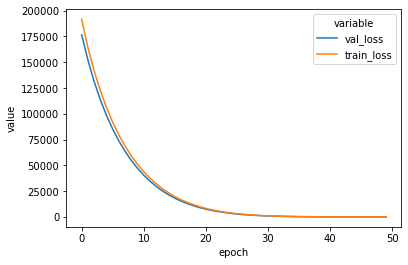

In [15]:
metrics = pd.read_csv(f"{logger.log_dir}/metrics.csv")
metrics_melt = pd.melt(metrics, id_vars=["epoch", "step"]).dropna()
g = sns.lineplot(x="epoch", y="value", hue="variable", data=metrics_melt)
g.get_figure().savefig(f"{logger.log_dir}/losses.png", dpi=300)